 Introduction to tracking by detection

"*Tracking by Detection*" is a popular approach in the field of computer vision for object tracking, particularly in contexts like multi-object tracking (MOT). It consists of two main phases: detection and tracking, which are applied sequentially to maintain the identities of objects across frames in a video.

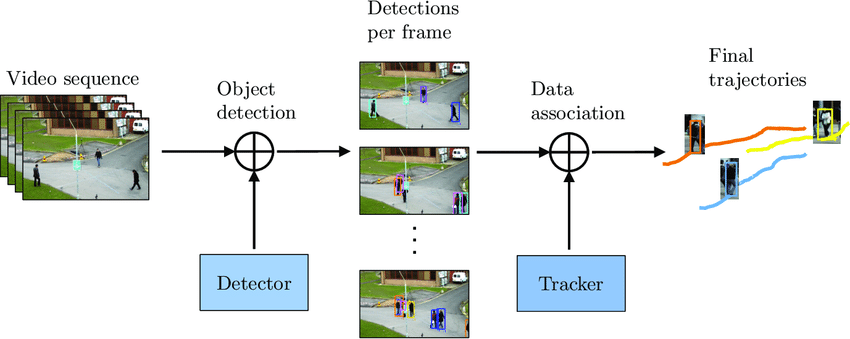

Image from https://arxiv.org/abs/1411.7935


## Detection:
First, in each frame of the video or image sequence, objects of interest are detected. This could be anything from cars, people, or any specific objects.
Pre-trained object detection models, like YOLO (You Only Look Once), SSD (Single Shot MultiBox Detector), or Faster R-CNN, can be used for this purpose. In the case of person tracking, we can use any person detector. In the context of this lab, we will use the multi-person pose estimator "*OpenPose*".

##Tracking:
Once objects are detected, the tracking algorithm comes into play. The algorithm keeps the identity of each object consistent across different frames.
There are different methods to associate detections across frames such as the Hungarian algorithm, Kalman filters, and Particle filters. In this lab, we will use employ a simple hungarian algorithm

# Data
First, let’s begin by downloading the necessary video file and the library that we will be utilizing in this lab.

In [ ]:
# download a publicly available video (or just get your own)
!git clone https://github.com/xuexingyu24/Real-time-human-pose-estimation-by-pytorch.git
%cd Real-time-human-pose-estimation-by-pytorch/
!wget http://stelat.eu/wp-content/uploads/2023/10/video-tp.tar.gz
!tar xzvf video-tp.tar.gz

To allow visualisation in Colab, we generate a low resolution video. We also create a parameter *break_frame* that indicates how many frames we will work on before stopping our program. When you develop, it's recommended to set it to a low value (eg. 15) to save time and compute. Once your tracker seems working, you can try on a longer sequence.  

In [ ]:
import cv2
import imageio
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from skimage.transform import resize
from IPython.display import HTML

#we scale down the resolution by 4
scale_res=0.25
break_frame = 150 # variable used to process only the first frames of the video when debugging
input_video="img1/out.mp4"

cap = cv2.VideoCapture(input_video)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
# Define the codec and create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'MP4V') #codec
dim = (int(width*scale_res), int(height*scale_res))
out = cv2.VideoWriter('video_lowres.mp4', fourcc, 20.0, dim)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:# or counter not in all_poses:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # write the flipped frame
    out.write(cv2.resize(frame,dim))

# Release everything if job is finished
cap.release()
out.release()
cv2.destroyAllWindows()

Let's look at the beginning of the video.

In [ ]:
def display_video(video):
    fig = plt.figure(figsize=(10,5))  #Display size specification
    mov = []
    for i in range(min(len(video),break_frame)):  #Append videos one by one to mov
        frame=video[i]
        img = plt.imshow(frame, animated=True)
        plt.axis('off')
        mov.append([img])

    #Animation creation
    anime = animation.ArtistAnimation(fig, mov, interval=250, repeat_delay=1000)
    plt.close()
    return anime
video = imageio.mimread("video_lowres.mp4")  #Loading video

HTML(display_video(video).to_html5_video())  #Inline video display in HTML5

# Detection
To detect the people, we will use OpenPose that estimates a skeleton (="*body pose*") for every detected person.  We start with downloading the pretrained model. We provide the code for estimating detections. You can simply read the code to understand what is done in every line (You may need to explore the github repo we cloned above).  

In [ ]:
# Import necessary libraries and modules
from model import bodypose_model, PoseEstimationWithMobileNet
from Demo_picture import Net_Prediction
from utils.util import *
import time
import torch
import numpy as np
import argparse
import os
import sys

# Define a configuration class for Pose estimation
class PoseConfig:
    def __init__(self, backbone='Mobilenet', scale=0.3, show=(-1, 2), thre=0.1):
        self.backbone = backbone
        self.scale = scale # resolution scale parameter, used to reduce computation cost of detection
        self.show = show
        self.thre = thre

def get_list_dets(subset, candidate,scale):
    dets=[[] for n in range(len(subset))]
    for i in range(18): # for each body joint
        for n in range(len(subset)): # for each detection of the i^th joint
            index = int(subset[n][i]
            if index == -1: # if not detected
                coord= [-1,-1,]
            x, y = candidate[index][0:2]
            coord=[int(x/scale), int(y/scale)]
            dets[n].append(coord)
    return dets


# Create a configuration object with default values
config = PoseConfig()

# Determine the device for processing (CPU or GPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Load the appropriate Pose estimation model based on the selected backbone. In this lab we will use mobileNet to reduce the computation cost
if config.backbone == 'CMU':
    model = bodypose_model().to(device)
    model.load_state_dict(torch.load('weights/bodypose_model', map_location=lambda storage, loc: storage))
elif config.backbone == 'Mobilenet':
    model = PoseEstimationWithMobileNet().to(device)
    model.load_state_dict(torch.load('weights/MobileNet_bodypose_model', map_location=lambda storage, loc: storage))

# Set the model to evaluation mode
model.eval()

# Print a message indicating successful model loading
print('openpose {} model is successfully loaded...'.format(config.backbone))

# Open a video file for processing
cap = cv2.VideoCapture("img1/out.mp4")

# Read the first frame from the video
_, frame = cap.read()

# Initialize variables
current = 0

all_dets = {}  # Dictionary to store detections for each frame

# Loop to process video frames
while True:
    isSuccess, frame = cap.read()
    if isSuccess and current < break_frame:
        start_time = time.time()

        # Resize the frame for processing
        imageToTest = cv2.resize(frame, (0, 0), fx=config.scale, fy=config.scale, interpolation=cv2.INTER_CUBIC)

        # Perform Pose estimation on the resized frame
        heatmap, paf = Net_Prediction(model, imageToTest, device, backbone=config.backbone)
        all_peaks = peaks(heatmap, config.thre)

        if current % 10 == 0:
            print("processing frame", current)

        # Perform post-processing to obtain candidate keypoints and body part connections. If you don't understand these lines, you can look at the slides of the last lecture to see how openpose works
        connection_all, special_k = connection(all_peaks, paf, imageToTest)
        candidate, subset = merge(all_peaks, connection_all, special_k)

        # Convert the subset and candidate keypoints to a list of detections
        all_dets[current] = get_list_dets(subset, candidate, config.scale)
        current += 1
    else:
        break

# Release the video capture object
cap.release()


# Visualization
We provide some visualization function. These functions consists in deplaying a detection or a list of detections. The colors are provided just to facilitate visualization.

In [ ]:
colors = [[255, 0, 0], [255, 85, 0], [255, 170, 0], [255, 255, 0], [170, 255, 0], [85, 255, 0], [0, 255, 0], \
          [0, 255, 85], [0, 255, 170], [0, 255, 255], [0, 170, 255], [0, 85, 255], [0, 0, 255], [85, 0, 255], \
          [170, 0, 255], [255, 0, 255], [255, 0, 170], [255, 0, 85]]

def draw_det(image,d,color,scale,track_id=None):
  """
  Draw the skeleton on the image.

  Args:
      image (numpy.ndarray): The input image.
      skeleton (list): List of points in the skeleton to be drawn.
      color (tuple): Color (B, G, R) for drawing.
      scale (float): Scaling factor for the coordinates.
      track_id (int): used only to display tracks

  Returns:
      None
  """
  position_text=None
  for p in d:
     x, y = p[0:2]
     if x!=-1 or y!=-1:
        cv2.circle(image, (int(x*scale), int(y*scale)), int(5*scale+1), color, thickness=int(5*scale+1))
        if track_id is not None and position_text is None:
            position_text=(int(x*scale)+5, int(y*scale))
            image = cv2.putText(image, str(track_id), position_text, cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2, cv2.LINE_AA)


def draw_dets(image,dets,scale=1.0):
  """
  draw all the skeletons in dets on the image

  Returns:
      None
  """
  for n,d in enumerate(dets):
    draw_det(image,d,colors[n%18],scale)


In [ ]:
# Set the scale factor for resizing the frames
scale_res = 0.25

# Open the video file for reading
cap = cv2.VideoCapture(input_video)

# Get the width and height of the video frames
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))   # Get the width of the frames
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))  # Get the height of the frames

# Define the codec and create a VideoWriter object for the output video
fourcc = cv2.VideoWriter_fourcc(*'MP4V')  # Define the codec for the output video
dim = (int(width * scale_res), int(height * scale_res))  # Define the dimensions for the output frames
out = cv2.VideoWriter('output_lowres.mp4', fourcc, 20.0, dim)  # Create VideoWriter object

current = 0  # Initialize a variable to keep track of the current frame

# Loop through the video frames and write them to the output video
while cap.isOpened() and current < break_frame:
    ret, frame = cap.read()  # Read a frame from the input video

    if not ret:  # Check if the frame was successfully read
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # Resize the frame to the specified dimensions and write it to the output video
    out.write(cv2.resize(frame, dim))

# Release the input and output video objects
cap.release()  # Release the input video
out.release()  # Release the output video

cv2.destroyAllWindows()

Can't receive frame (stream end?). Exiting ...


We can visualize all the detections. Each detection has a random color corresponding to the random order of the detections.

In [ ]:
def display_det(video):
    fig = plt.figure(figsize=(10,5))  #Display size specification
    mov = []
    for i in range(min(len(video),break_frame)):  #Append videos one by one to mov
        frame=video[i]
        frame = cv2.putText(frame, str(i),(0,25), cv2.FONT_HERSHEY_SIMPLEX , 1,  (128,128,128),2,cv2.LINE_AA) # Add the index of the frame on each frame
        if i%10==0:
          print("processing frame", i)
        draw_dets(frame,all_dets[i],scale_res)
        img = plt.imshow(frame, animated=True)
        plt.axis('off')
        mov.append([img])

    #Animation creation
    anime = animation.ArtistAnimation(fig, mov, interval=250, repeat_delay=1000)

    plt.close()
    return anime
video = imageio.mimread("output_lowres.mp4")  #Loading video

HTML(display_det(video).to_html5_video())  #Inline video display in HTML5

processing frame 0
processing frame 10
processing frame 20
processing frame 30
processing frame 40
processing frame 50
processing frame 60
processing frame 70
processing frame 80
processing frame 90
processing frame 100
processing frame 110
processing frame 120
processing frame 130
processing frame 140


# Tracker implementation
Let's create a class Track to model each track.

In [ ]:
class Track:
    def __init__(self, pose, track_id, t):
        # Initialize a Track object with a pose (if provided) at time t
        if pose is None:
            self.poses = {}  # If no pose is provided, initialize an empty dictionary
        else:
            self.poses = {t: pose}  # Otherwise, initialize the dictionary with the provided pose at time t
        self.track_id = track_id  # Assign the track index
        self.last_appearance = 0  # Initialize the counter for frames without detection
        self.alive = True  # Initialize the flag to indicate that the track is alive

    def update_pose(self, pose, t):
        # Update the pose for the person at time t
        self.poses[t] = pose  # Add or overwrite the pose in the dictionary


The definition of a distance metric is crucial in the "Tracking by Detection" paradigm to measure the dissimilarity between detected objects and existing tracks. When using the L1 distance, the calculation is straightforward by summing the absolute differences between coordinates. However, when some body parts are missing in the detection due to occlusions or imperfect detection models, special care should be taken.

The following function takes the coordinates of some tracker 'track', and returns the distance w.r.t the coordinates of some detection 'det'.

In [ ]:
def distance_poses(track, det):
    #TODO

    return dist

Lets define some other functions that will be usefull to create, update or delete tracks.

First we create a function that determines if a detection does not correspond to any track.

This function calculates the minimum distance between the given detection 'det' and all existing tracks at time 't' and check if the minimum distance is greater than the specified threshold. This function returns a boolean value determining if the above mentioned condition is True or False.

In [ ]:

def is_new(det, tracks, t, threshold):
    # Calculate the minimum distance between the given detection 'det' and all existing tracks at time 't' and Check if the minimum distance is greater than the specified threshold
    # TODO
    return #...

We now implement another key function of a tracker: the death process. The goal of this procedure is to determine which tracks should be removed from the list of the existing tracks. In practice, tracks must be killed when people leave the scene. To do so, we we check the last_appearance counter of the class Track, if it's greater than the delay, we set to False the instance alive in the class Track. We have to check all the trackers in tracks.

In [ ]:

def death_process(tracks, delay):
        # Check all the tracks and set the 'alive' flag of the track to False if the track has not been detected for more than 'delay'


Now it's time to implement the *assign()* function that matches the current detections to the past tracks. In this task we formulate the matching problem as a linear sum assignment problem. We recommend using the scipy implementationwhich is well described in their [online documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html).

In [ ]:
from scipy.optimize import linear_sum_assignment


#def is_valid_det(det, confidence=0.5):
#  pose=np.array(det)
#  test=np.where(pose[:,0]==-1, 0, 1)
#  valid=np.sum(test)/pose.shape[0]
#  return valid > confidence




def assign(tracks, dets, t, threshold):
    if t % 10 == 0:
        print("frame ", t)

    # Create a dictionary of alive tracks
    alive_tracks = #...

    # classify the detection in two groups: completely new tracks and detection to track
    new_pers = []
    dets_to_track = []
    for det in dets:
        #...

    # Compute the cost matrix that contains the cost of associating each detection with each alive track
    cost = np.empty((len(alive_tracks), len(dets_to_track)))
    #...Fill the matrix


    # Estimate the best match using the Hungarian algorithm
    row_ind, col_ind = linear_sum_assignment(cost)

    # If some alive tracks are not associated with any detection, copy their last position (poses[t]=poses[t-1])
    for id in alive_tracks:
        if  #.... missing detection for this track
            track_id = alive_tracks[id].track_id
            tracks[track_id].last_appearance += 1  # Increment the number of frames without detection
            tracks[track_id].update_pose(alive_tracks[id].poses[t - 1], t)

    # If there are more detections than tracks, consider creating new tracks
    if #.....
                new_pers.append(dets_to_track[id])

    # For each pair (alive track, detection), update the track or create a new track if the match is above a threshold
    for alive_track, det_id in zip(row_ind, col_ind):
        if cost[alive_track, det_id] < threshold:  # If this is a valid assignment
            # update the pose and the last_appearance field to 0
            #...

        else: # the detection is to far to be valid
            # Update the track with the previous position
            #...

            # Create a new track for the detection
            #...

    # Add new tracks for detections that weren't associated with any existing tracks
    for det in new_pers:
        tracks[len(tracks)] = Track(det, len(tracks), t)





Now all our functions are implemented. We can simply  iterate over all the frames.

In [ ]:
threshold=1.0 # threshold to allow detection-track matching

# Iterate through frames in the 'all_dets' list
for frame_id in range(len(all_dets)):
    # Get detections for the current frame and filter out invalid ones if necessary
    dets = all_dets[frame_id]  # [d for d in all_dets[frame_id] if is_valid_det(d)]

    if frame_id == 0:
        # Initialize tracks with the first frame
        all_tracks = #...
    else:
        # Assign detections to existing tracks or create new tracks
        assign(all_tracks, dets, frame_id,threshold)

    # Process tracks to mark as non-alive if they haven't been detected for a certain number of frames
    death_process(all_tracks, delay=3)

We can visualize the tracking results.

In [ ]:
def display_tracks(video):
    # Create a figure for displaying the video frames
    fig = plt.figure(figsize=(10, 5))

    # Initialize an empty list 'mov' to store video frames
    mov = []

    # Iterate through the video frames (up to 'break_frame')
    for i in range(min(len(video), break_frame)):
        frame = video[i]  # Get the current frame from the video

        # Add frame number as text to the frame
        frame = cv2.putText(frame, str(i), (0, 25), cv2.FONT_HERSHEY_SIMPLEX, 2, (128, 128, 128), 3, cv2.LINE_AA)

        if i % 10 == 0:
            print("processing frame", i)

        # Draw detected tracks on the frame
        for t in all_tracks:
            if i in all_tracks[t].poses.keys() and len(all_tracks[t].poses)>5:
                draw_det(frame, all_tracks[t].poses[i], colors[all_tracks[t].track_id % 18], scale_res, all_tracks[t].track_id)

        img = plt.imshow(frame, animated=True)  # Display the frame as an image
        plt.axis('off')  # Turn off axis labels

        mov.append([img])  # Append the frame to the 'mov' list

    # Create an animation using the 'mov' frames
    anime = animation.ArtistAnimation(fig, mov, interval=250, repeat_delay=1000)

    plt.close()  # Close the figure
    return anime

# Load the video frames from the 'output_lowres.mp4' video file
video = imageio.mimread('output_lowres.mp4')

# Display the animation inline in HTML5
HTML(display_tracks(video).to_html5_video())



What problems did you notice in your results? We won't have enough time to fix these problems in this lab but, we can study more to understand how to solve these issues. For this task, please read [this paper](https://arxiv.org/pdf/1703.07402.pdf) and suggest two changes to improve our current work. This paper talks about using boxes instead of skeletons, but the main ideas and issues are very similar.